# Task #3: Count Samples per Fault Category

**Goal:** Count samples for Normal, InnerRaceFault, and OuterRaceFault
across train/val/test splits, and check if the splits are balanced.

In [7]:
from collections import Counter
from pathlib import Path
import scipy.io

import matplotlib.pyplot as plt
import numpy as np

In [8]:
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
print("Reading from:", DATA_DIR.resolve())

SPLITS = {
    "train": ("train.mat", "trainLabels"),
    "val":   ("val.mat",   "valLabels"),
    "test":  ("test.mat",  "testLabels"),
}

CATEGORIES = ["Normal", "InnerRaceFault", "OuterRaceFault"]


def load_labels(filename, label_key):
    mat = scipy.io.loadmat(DATA_DIR / filename)
    return [label[0] for label in mat[label_key].flatten()]

Reading from: /Users/bezawitgessesse/Desktop/mathworks-1d/MathWorks-1D-unlocking-embedded-ai-through-efficient-compression/data


In [9]:
all_counts = {}
all_labels = {}

for split_name, (fname, label_key) in SPLITS.items():
    labels = load_labels(fname, label_key)
    all_labels[split_name] = labels
    counts = Counter(labels)
    all_counts[split_name] = counts

    print(f"\n{split_name.upper()} - {len(labels)} total samples")
    for cat in CATEGORIES:
        print(f"  {cat:16s}: {counts.get(cat, 0)}")


TRAIN - 393 total samples
  Normal          : 131
  InnerRaceFault  : 131
  OuterRaceFault  : 131

VAL - 27 total samples
  Normal          : 9
  InnerRaceFault  : 9
  OuterRaceFault  : 9

TEST - 102 total samples
  Normal          : 34
  InnerRaceFault  : 34
  OuterRaceFault  : 34


In [10]:
print(f"{'Split':10s}" + "".join(f"{c:18s}" for c in CATEGORIES) + "Total")
for split_name, counts in all_counts.items():
    total = sum(counts.values())
    row = f"{split_name:10s}" + "".join(f"{counts.get(c, 0):18d}" for c in CATEGORIES) + f"{total}"
    print(row)

Split     Normal            InnerRaceFault    OuterRaceFault    Total
train                    131               131               131393
val                        9                 9                 927
test                      34                34                34102


In [11]:
for split_name, counts in all_counts.items():
    values = [counts.get(c, 0) for c in CATEGORIES]
    if len(set(values)) > 1:
        print(f"[!] {split_name} is NOT balanced: {dict(zip(CATEGORIES, values))}")
    else:
        print(f"[OK] {split_name} is balanced ({values[0]} per class).")

[OK] train is balanced (131 per class).
[OK] val is balanced (9 per class).
[OK] test is balanced (34 per class).


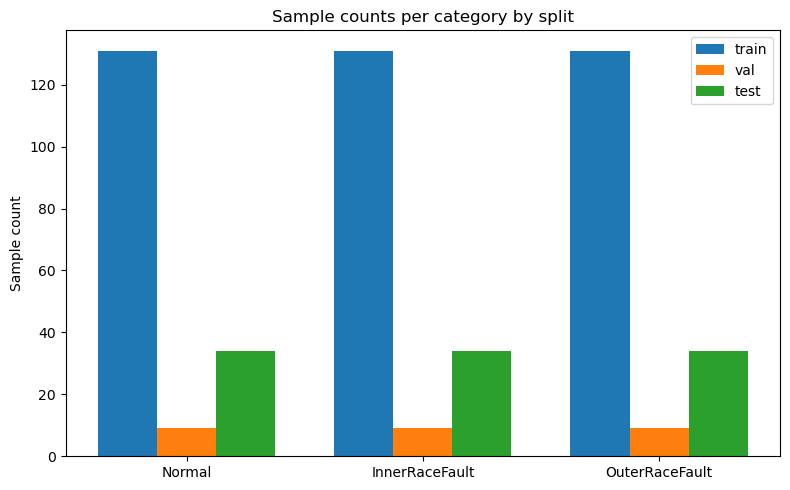

In [12]:
x = np.arange(len(CATEGORIES))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, (split_name, counts) in enumerate(all_counts.items()):
    values = [counts.get(c, 0) for c in CATEGORIES]
    ax.bar(x + i * width, values, width, label=split_name)

ax.set_xticks(x + width)
ax.set_xticklabels(CATEGORIES)
ax.set_ylabel("Sample count")
ax.set_title("Sample counts per category by split")
ax.legend()
plt.tight_layout()
plt.show()